In [1]:
import yaml
import torch
import random
import pickle
import numpy as np
from PIL import Image
from dotmap import DotMap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.transforms import Affine2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Use matplotlib's tex rendering
import matplotlib
matplotlib.rcParams['text.usetex'] = True

from pud.collectors.collector import Collector
from pud.utils import set_global_seed, set_env_seed
from pud.visualizers.visualize import plot_agent_paths
from pud.algos.vision.vision_agent import LagVisionUVFDDPG
from pud.collectors.constrained_collector import ConstrainedCollector
from pud.envs.safe_pointenv.pb_sampler import sample_pbs_by_agent, load_pb_set
from pud.envs.habitat_navigation_env import GoalConditionedHabitatPointWrapper
from pud.envs.safe_habitatenv.safe_habitat_wrappers import safe_habitat_env_load_fn
from pud.algos.policies import VisualMultiAgentSearchPolicy, VisualConstrainedMultiAgentSearchPolicy
from pud.envs.safe_habitatenv.safe_habitat_wrappers import SafeGoalConditionedHabitatPointWrapper, SafeGoalConditionedHabitatPointQueueWrapper

#### Load the evaluation configuration

In [2]:
illustration_pb_file="pud/plots/data/illustration_pbs.pkl"
unconstrained_ckpt_file="models/SC3_Staging_11/ckpt/ckpt_0722500"
illustration_png_file="pud/plots/figures/paper/sc3_staging_11.png"
config_file="models/SC3_Staging_11/lag/2024-09-11-15-53-23/bk/config.yaml"
constrained_ckpt_file="models/SC3_Staging_11/lag/2024-09-11-15-53-23/ckpt/ckpt_0460000"

with open(config_file, 'r') as f:
    config = yaml.safe_load(f)
config = DotMap(config)

# User defined parameters for evaluation
config.device = "cuda:0"
config.agent_cost_kwargs.cost_limit = 2.0
config.replay_buffer.max_size = 1000

set_global_seed(config.seed)

#### Load the evaluation environment

In [3]:
gym_env_wrappers = []
gym_env_wrapper_kwargs = []
for wrapper_name in config.wrappers:
    if wrapper_name == "GoalConditionedHabitatPointWrapper":
        gym_env_wrappers.append(GoalConditionedHabitatPointWrapper)
        gym_env_wrapper_kwargs.append(config.wrappers[wrapper_name].toDict())
    elif wrapper_name == "SafeGoalConditionedHabitatPointWrapper":
        gym_env_wrappers.append(SafeGoalConditionedHabitatPointWrapper)
        gym_env_wrapper_kwargs.append(config.wrappers[wrapper_name].toDict())
    elif wrapper_name == "SafeGoalConditionedHabitatPointQueueWrapper":
        gym_env_wrappers.append(SafeGoalConditionedHabitatPointQueueWrapper)
        gym_env_wrapper_kwargs.append(config.wrappers[wrapper_name].toDict())

eval_env = safe_habitat_env_load_fn(
    env_kwargs=config.env.toDict(),
    cost_f_args=config.cost_function.toDict(),
    cost_limit=config.agent_cost_kwargs.cost_limit,
    max_episode_steps=config.time_limit.max_episode_steps,
    gym_env_wrappers=gym_env_wrappers,  # type: ignore
    wrapper_kwargs=gym_env_wrapper_kwargs,
    terminate_on_timeout=True,
    )

set_env_seed(eval_env, config.seed + 2)

Renderer: NVIDIA GeForce RTX 4090/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 570.169
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits
[INFO] Calling the APSP construction function


[18:42:58:242823]:[Error]:[Metadata] SceneDatasetAttributesManager.cpp(305)::validateMap : `navmesh_instances` Key : `Baked_sc4_staging_00` Value : `navmeshes/Baked_sc4_staging_00.navmesh` not found on disk as absolute path or relative to `external_data/replica_cad/replica_cad_baked_lighting`
[18:42:58:242847]:[Error]:[Metadata] SceneDatasetAttributesManager.cpp(305)::validateMap : `navmesh_instances` Key : `Baked_sc4_staging_01` Value : `navmeshes/Baked_sc4_staging_01.navmesh` not found on disk as absolute path or relative to `external_data/replica_cad/replica_cad_baked_lighting`
[18:42:58:242853]:[Error]:[Metadata] SceneDatasetAttributesManager.cpp(305)::validateMap : `navmesh_instances` Key : `Baked_sc4_staging_02` Value : `navmeshes/Baked_sc4_staging_02.navmesh` not found on disk as absolute path or relative to `external_data/replica_cad/replica_cad_baked_lighting`
[18:42:58:242858]:[Error]:[Metadata] SceneDatasetAttributesManager.cpp(305)::validateMap : `navmesh_instances` Key : `

  0%|          | 0/206 [00:00<?, ?it/s]

APSP construction time in (s):  0.021932125091552734
[INFO] Skipping the reset in HabitatNavigationEnv.__init__ because setup is not ready yet
[INFO] SafeHabitatNavigationEnv Setup: 0.007732391357421875 s


/scratch/miniconda3/envs/cc-sorb/lib/python3.9/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


#### Load the inference agent

In [4]:
obs_dim = eval_env.observation_space['observation'].shape[0]  # type: ignore
goal_dim = obs_dim
state_dim = obs_dim + goal_dim
action_dim = eval_env.action_space.shape[0]  # type: ignore
max_action = float(eval_env.action_space.high[0])  # type: ignore
config.agent["action_dim"] = eval_env.action_space.shape[0]  # type: ignore
config.agent["max_action"] = float(eval_env.action_space.high[0])  # type: ignore
print(f'Obs dim: {obs_dim},\n'
      f'Goal dim: {goal_dim},\n'
      f'State dim: {state_dim},\n'
      f'Action dim: {action_dim},\n'
      f'Max action: {max_action}')


agent = LagVisionUVFDDPG(
    width=config.env.simulator_settings.width,
    height=config.env.simulator_settings.height,
    in_channels=4,
    act_fn=torch.nn.SELU,
    encoder="VisualEncoder",
    device=config.device,
    **config.agent.toDict(),
    cost_kwargs=config.agent_cost_kwargs.toDict(),
)

agent.load_state_dict(torch.load(constrained_ckpt_file, map_location=config.device))
agent.to(torch.device(config.device))
agent.eval()

Obs dim: 4,
Goal dim: 4,
State dim: 8,
Action dim: 2,
Max action: 1.0


LagVisionUVFDDPG(
  (actor): VisualGoalConditionedActor(
    (encoder): VisualEncoder(
      (conv_net): Sequential(
        (0): Conv2d(4, 16, kernel_size=(8, 8), stride=(4, 4))
        (1): SELU()
        (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(4, 4))
        (3): SELU()
        (4): Flatten(start_dim=1, end_dim=-1)
      )
      (l1): Linear(in_features=128, out_features=256, bias=True)
    )
    (l1): Linear(in_features=512, out_features=256, bias=True)
    (l2): Linear(in_features=256, out_features=256, bias=True)
    (l3): Linear(in_features=256, out_features=2, bias=True)
  )
  (actor_target): VisualGoalConditionedActor(
    (encoder): VisualEncoder(
      (conv_net): Sequential(
        (0): Conv2d(4, 16, kernel_size=(8, 8), stride=(4, 4))
        (1): SELU()
        (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(4, 4))
        (3): SELU()
        (4): Flatten(start_dim=1, end_dim=-1)
      )
      (l1): Linear(in_features=128, out_features=256, bias=True)
    )
    (l

#### Sample a replay buffer to form our search graph

In [5]:
rb_vec_grid, rb_vec_visual = ConstrainedCollector.sample_initial_unconstrained_states(eval_env, config.replay_buffer.max_size, habitat=True)

agent.load_state_dict(torch.load(unconstrained_ckpt_file, map_location=config.device))
agent.to(torch.device(config.device))
agent.eval()
pdist = agent.get_pairwise_dist(rb_vec_visual, aggregate=None)  # type: ignore

agent.load_state_dict(torch.load(constrained_ckpt_file, map_location=config.device))
pcost = agent.get_pairwise_cost(rb_vec_visual, aggregate=None)  # type: ignore

#### Sample (start, goal) problems for the agent

In [6]:
illustration_problems = pickle.load(open(illustration_pb_file, "rb"))
single_agent_problem = [illustration_problems[0]]
multi_agent_problems = [illustration_problems[0], illustration_problems[5], illustration_problems[6], illustration_problems[7]]

problems = single_agent_problem.copy()
eval_env.set_use_q(True) # type: ignore
eval_env.set_prob_constraint(1.0) # type: ignore

In [7]:
def add_inset_axes(fig, ax, eval_env, start, goal, obs, wps=None, agent_id=0, xlim=(10, 20), ylim=(9, 18), offsets=(0, 0)):
    h, w = eval_env.get_map_height(), eval_env.get_map_width()
    axs_inset_temp = inset_axes(ax, width="100%", height="100%", bbox_to_anchor=(0, -1.2, 1, 1), bbox_transform=ax.transAxes, loc='lower left', borderpad=0.0)
    axs_inset_bounds = axs_inset_temp.get_position()
    axs_inset_bounds = axs_inset_bounds.transformed(Affine2D().translate(0, -axs_inset_bounds.height * 1.1))
    axs_inset = fig.add_axes(axs_inset_bounds)  # type: ignore
    im = np.asarray(Image.open(illustration_png_file))
    axs_inset.imshow(im, extent=[0, h+offsets[0], 0, w+offsets[1]])
    for axins in [axs_inset, axs_inset_temp]:
        axins.set_xticks([])
        axins.set_yticks([])
        axins.set_xlim(*xlim)
        axins.set_ylim(*ylim)
    for spine in axs_inset_temp.spines.values():
        spine.set_visible(False)
    axs_inset = plot_agent_paths(agent_id, start, goal, obs, "", axs_inset, wps=wps, use_agent_id=False)
    return axs_inset

## Single-Agent Comparisons

### Constrained Low-Level Policy

In [8]:
agent.to(torch.device(config.device))
agent.eval()

eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

start, goal, constrained_observations, _, _, constrained_records = ConstrainedCollector.get_trajectories(
    agent,
    eval_env,
    1,
    habitat=True,
    wait=True,
    threshold=1e-3,
)

### Constrained Low-Level Policy with Graph Search

In [9]:
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config = {
    "seed": None,
    "use_experience": True,
    "use_cardinality": True,
    "collision_radius": 0.0,
    "risk_attribute": "cost",
    "split_strategy": "disjoint",
    "edge_attributes": ["step"],
    "max_distance": eval_env.max_goal_dist,  # type: ignore
    "max_time": 60,
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/cbs",
}

search_policy = VisualConstrainedMultiAgentSearchPolicy(
    agent=agent, 
    rb_vec=(rb_vec_grid, rb_vec_visual),
    n_agents=1,
    pdist=pdist, 
    pcost=pcost, 
    open_loop=True,
    cbs_config=cbs_config,
    no_waypoint_hopping=True,
    max_search_steps=3,
    max_cost_limit=0.5 * config.agent_cost_kwargs.cost_limit,
    ckpts={
        "unconstrained": unconstrained_ckpt_file,
        "constrained": constrained_ckpt_file,
    }
)
start, goal, constrained_search_observations, constrained_search_waypoints, _, constrained_search_records = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    1,
    habitat=True,
    wait=True,
    threshold=1e-3,
)

/scratch/Work/Multi_Agent_Research/Hierarchical_Constrained_SORB/cc-sorb-rev/pud/algos/vision/vision_agent.py:360: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  observation=torch.FloatTensor(state["observation"]),


### Lagrangian Graph Search

In [10]:
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config = {
    "seed": None,
    "use_experience": True,
    "use_cardinality": True,
    "collision_radius": 0.0,
    "risk_attribute": "cost",
    "split_strategy": "disjoint",
    "edge_attributes": ["step", "cost"],
    "max_distance": eval_env.max_goal_dist,  # type: ignore
    "max_time": 60,
    "lagrangian": agent.lagrange.lagrangian_multiplier.data.numpy(),
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/cbs",
}

search_policy = VisualConstrainedMultiAgentSearchPolicy(
    agent=agent,
    rb_vec=(rb_vec_grid, rb_vec_visual),
    n_agents=1,
    pdist=pdist,
    pcost=pcost,
    open_loop=True,
    cbs_config=cbs_config,
    no_waypoint_hopping=True,
    ckpts={
        "unconstrained": unconstrained_ckpt_file,
        "constrained": constrained_ckpt_file,
    },
)

start, goal, lagrangian_search_observations, lagrangian_search_waypoints, _, lagrangian_search_records = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    1,
    habitat=True,
    wait=True,
    threshold=1e-3,
)

### Biobjective Search

In [11]:
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config = {
    "seed": None,
    "use_experience": False,
    "collision_radius": 0.0,
    "use_cardinality": False,
    "risk_attribute": "cost",
    "use_multi_objective": True,
    "split_strategy": "disjoint",
    "edge_attributes": ["step", "cost"],
    "max_distance": eval_env.max_goal_dist,  # type: ignore
    "max_time": 60,
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/bocbs",
}

search_policy = VisualConstrainedMultiAgentSearchPolicy(
    agent=agent,
    rb_vec=(rb_vec_grid, rb_vec_visual),
    n_agents=1,
    pdist=pdist,
    pcost=pcost,
    open_loop=True,
    cbs_config=cbs_config,
    no_waypoint_hopping=True,
    ckpts={
        "unconstrained": unconstrained_ckpt_file,
        "constrained": constrained_ckpt_file,
    },
)

start, goal, biobjective_search_observations, biobjective_search_waypoints, _, biobjective_search_records = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    1,
    habitat=True,
    wait=True,
    threshold=1e-3,
)

First solution time (s):  3.0818538665771484


### Collect Bounds (Needed to compute bounds for $\Delta$) 

In [12]:
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config = {
    "seed": None,
    "use_experience": True,
    "use_cardinality": True,
    "collision_radius": 0.0,
    "risk_attribute": "cost",
    "split_strategy": "disjoint",
    "max_distance": eval_env.max_goal_dist,  # type: ignore
    "lb_save_path": "pud/plots/exps/lb_centerdot.npy",
    "ub_save_path": "pud/plots/exps/ub_centerdot.npy",
    "max_time": 60,
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/cbs",
}

search_policy = VisualConstrainedMultiAgentSearchPolicy(
    agent=agent,
    rb_vec=(rb_vec_grid, rb_vec_visual),
    n_agents=1,
    pdist=pdist,
    pcost=pcost,
    open_loop=True,
    cbs_config=cbs_config,
    max_cost_limit=np.inf,
    no_waypoint_hopping=True,
    ckpts={
        "unconstrained": unconstrained_ckpt_file,
        "constrained": constrained_ckpt_file,
    },
)

cbs_config["edge_attributes"] = ["cost"]
start, goal, _, _, _, _ = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    1,
    habitat=True,
    wait=True,
    threshold=1e-3,
)

cbs_config["edge_attributes"] = ["step"]
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore
start, goal, _, _, _, _ = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    1,
    habitat=True,
    wait=True,
    threshold=1e-3,
)
bounds_data = {"cbs": {}, "lb": None, "ub": None}
cbs_lb = np.load(cbs_config["lb_save_path"])
cbs_ub = np.load(cbs_config["ub_save_path"])
bounds_data["cbs"]["lb"] = cbs_lb[-1]
bounds_data["cbs"]["ub"] = cbs_ub[-1]

In [13]:
def compute_search_cost(waypoints, goals, agent):
    total_cost = 0.0
    for idx, wps in enumerate(waypoints):
        for i in range(len(wps)):
            if i == 0:
                continue
            prev_wp = wps[i - 1]
            curr_wp = wps[i]
            if (prev_wp == goals[idx]).all():
                continue
            edge_cost = agent.get_pairwise_cost([prev_wp], [curr_wp], aggregate="min")[0][0]
            total_cost += edge_cost
    return total_cost

### Risk Bounded Search with Uniform Allocater

In [14]:
RISK_PERCENTAGES = [0.0, 0.05, 0.25]
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config = {
    "seed": None,
    "use_experience": True,
    "use_cardinality": True,
    "collision_radius": 0.0,
    "risk_attribute": "cost",
    "split_strategy": "disjoint",
    "budget_allocater": "uniform",
    "edge_attributes": ["step", "cost"],
    "max_distance": eval_env.max_goal_dist,  # type: ignore
    "max_time": 60,
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/rbcbs",
}

search_policy = VisualConstrainedMultiAgentSearchPolicy(
    agent=agent,
    rb_vec=(rb_vec_grid, rb_vec_visual),
    n_agents=1,
    pdist=pdist,
    pcost=pcost,
    open_loop=True,
    cbs_config=cbs_config,
    max_cost_limit=np.inf,
    no_waypoint_hopping=True,
    ckpts={
        "unconstrained": unconstrained_ckpt_file,
        "constrained": constrained_ckpt_file,
    },
)

cbs_config["risk_bound"] = bounds_data["cbs"]["lb"] + RISK_PERCENTAGES[0] * (bounds_data["cbs"]["ub"] - bounds_data["cbs"]["lb"])

start, goal, rbu_search_observations_0, rbu_search_waypoints_0, _, rbu_search_records_0 = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    1,
    habitat=True,
    wait=True,
    threshold=1e-3,
)

In [15]:
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config["risk_bound"] = bounds_data["cbs"]["lb"] + RISK_PERCENTAGES[1] * (bounds_data["cbs"]["ub"] - bounds_data["cbs"]["lb"])

start, goal, rbu_search_observations_1, rbu_search_waypoints_1, _, rbu_search_records_1 = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    1,
    habitat=True,
    wait=True,
    threshold=1e-3,
)

In [16]:
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config["risk_bound"] = bounds_data["cbs"]["lb"] + RISK_PERCENTAGES[2] * (bounds_data["cbs"]["ub"] - bounds_data["cbs"]["lb"])

start, goal, rbu_search_observations_2, rbu_search_waypoints_2, _, rbu_search_records_2 = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    1,
    habitat=True,
    wait=True,
    threshold=1e-3,
)

#### Plot the single-agent comparison

In [17]:
def discretize_state(state):
    height, width = eval_env.get_map_height(), eval_env.get_map_width()
    (i, j) = np.floor(state).astype(np.int32)
    if i == height:
        i -= 1
    if j == width:
        j -= 1
    return i, j

In [18]:
def normalize_data(observations, normalization_factor, waypoints=None):
    search_observations, search_image_observations = [], []

    for agent_idx in range(len(observations)):
        agent_search_obs, agent_search_image_obs = [], []
        for obs in observations[agent_idx]:
            # agent_search_obs.append(discretize_state(obs[0]))
            agent_search_obs.append(obs[0] / normalization_factor)
            agent_search_image_obs.append(obs[1])
        search_observations.append(np.array(agent_search_obs))
        search_image_observations.append(np.array(agent_search_image_obs))
    if waypoints is None:
        return search_observations, search_image_observations, None, None

    search_waypoints, search_image_waypoints = [], []

    for agent_idx in range(len(observations)):
        agent_search_wps, agent_search_image_wps = [], []
        for wp in waypoints[agent_idx]:
            agent_search_wps.append(wp[0] / normalization_factor)
            # agent_search_wps.append(discretize_state(wp[0]))
            agent_search_image_wps.append(wp[1])
        search_waypoints.append(np.array(agent_search_wps))
        search_image_waypoints.append(np.array(agent_search_image_wps))
    return (search_observations, search_image_observations,
            search_waypoints, search_image_waypoints)

In [19]:
height, width = 1.0, 1.0
normalization_factor = np.array([height, width])

start = [start[0][0]] / normalization_factor
goal = [goal[0][0]] / normalization_factor

In [20]:
(
    constrained_observations,
    constrained_image_observations,
    *_
) = normalize_data(constrained_observations, normalization_factor)

(
    constrained_search_observations,
    constrained_search_image_observations,
    constrained_search_waypoints,
    constrained_search_image_waypoints,
) = normalize_data(
    constrained_search_observations,
    normalization_factor,
    constrained_search_waypoints,
)

(
    lagrangian_search_observations,
    lagrangian_search_image_observations,
    lagrangian_search_waypoints,
    lagrangian_search_image_waypoints,
) = normalize_data(
    lagrangian_search_observations,
    normalization_factor,
    lagrangian_search_waypoints,
)

(
    biobjective_search_observations,
    biobjective_search_image_observations,
    biobjective_search_waypoints,
    biobjective_search_image_waypoints,
) = normalize_data(
    biobjective_search_observations,
    normalization_factor,
    biobjective_search_waypoints,
)

(
    rbu_search_observations_0,
    rbu_search_image_observations_0,
    rbu_search_waypoints_0,
    rbu_search_image_waypoints_0,
) = normalize_data(
    rbu_search_observations_0, normalization_factor, rbu_search_waypoints_0
)

(
    rbu_search_observations_1,
    rbu_search_image_observations_1,
    rbu_search_waypoints_1,
    rbu_search_image_waypoints_1,
) = normalize_data(
    rbu_search_observations_1, normalization_factor, rbu_search_waypoints_1
)

(
    rbu_search_observations_2,
    rbu_search_image_observations_2,
    rbu_search_waypoints_2,
    rbu_search_image_waypoints_2,
) = normalize_data(
    rbu_search_observations_2, normalization_factor, rbu_search_waypoints_2
)

<>:22: DeprecationWarning: invalid escape sequence \%


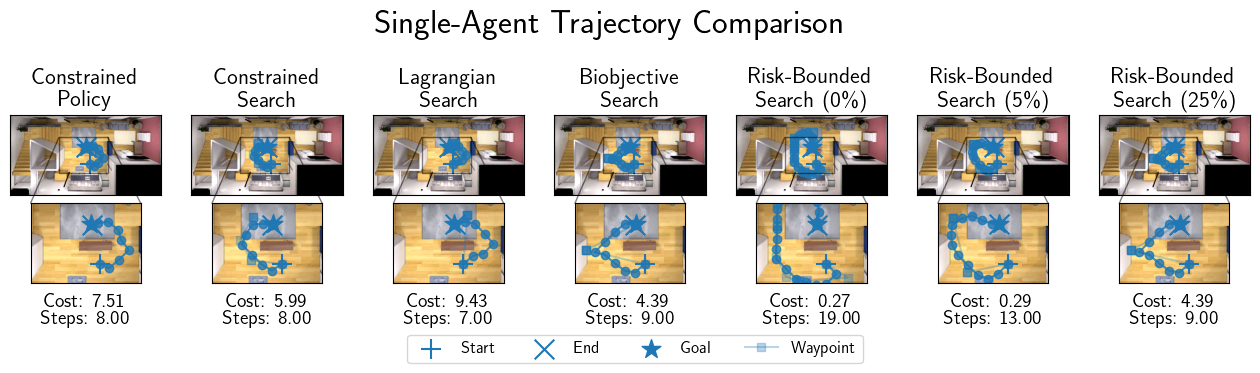

In [21]:
fig, axs = plt.subplots(1, 7, figsize=(16, 3))
height, width = eval_env.get_map_height(), eval_env.get_map_width()

# cost_map = binary_dilation(eval_env.get_map() == 1, structure=np.ones((3,3)), iterations=1)
from PIL import Image
for ax in axs:
    im = np.asarray(Image.open(illustration_png_file))
    h, w, _ = im.shape
    ax.imshow(im, extent=[0, height+2, 0, width])
    # ax.imshow(im, extent=[0, w, 0, h])
    # ax.imshow(eval_env.get_map()[:, ::-1].T, cmap="binary", interpolation="nearest", alpha=0.5, extent=[0, height, 0, width])
    # cmap = ax.imshow(cost_map[:, ::-1].T, cmap="hot_r", interpolation="nearest", alpha=0.5, extent=[0, height, 0, width])
    ax.set_xticks([])
    ax.set_yticks([])
    
# cbar = plt.colorbar(cmap, ax=axs, orientation="vertical", fraction=0.01, pad=0.04)
# cbar.ax.tick_params(size=0)
# cbar.set_ticks([0, 1, 2])

deltas = [bounds_data["cbs"]["lb"] + RISK_PERCENTAGES[i] * (bounds_data["cbs"]["ub"] - bounds_data["cbs"]["lb"]) for i in range(len(RISK_PERCENTAGES))]
delta_strings = [f"{deltas[i]:.2f}" for i in range(len(deltas))]
delta_percents = [f"{RISK_PERCENTAGES[i] * 100:.0f}\%" for i in range(len(RISK_PERCENTAGES))]  # type: ignore

methods_records_map = {
    "Constrained\nPolicy": (constrained_records, constrained_observations),
    "Constrained\nSearch": (constrained_search_records, constrained_search_observations, constrained_search_waypoints),
    "Lagrangian\nSearch": (lagrangian_search_records, lagrangian_search_observations, lagrangian_search_waypoints),
    "Biobjective\nSearch": (biobjective_search_records, biobjective_search_observations, biobjective_search_waypoints),
    "Risk-Bounded\nSearch 1": (rbu_search_records_0, rbu_search_observations_0, rbu_search_waypoints_0),
    "Risk-Bounded\nSearch 2": (rbu_search_records_1, rbu_search_observations_1, rbu_search_waypoints_1),
    "Risk-Bounded\nSearch 3": (rbu_search_records_2, rbu_search_observations_2, rbu_search_waypoints_2),
}
titles = methods_records_map.keys()

def calculate_costs_and_rewards(records, waypoints=None):
    cc = sum([record["cumulative_costs"] for record in records])
    if waypoints is not None:
        cc = compute_search_cost(waypoints, goal, agent)
    reward = np.mean([record["rewards"] for record in records])
    return cc, reward

agent_id = 0
for ax, title in zip(axs.flat, list(titles)):
    ax = plot_agent_paths(
        agent_id,
        start[agent_id],
        goal[agent_id],
        methods_records_map[title][1][agent_id],
        title,
        ax,
        wps=methods_records_map[title][2][agent_id] if "Search" in title else None,
        use_agent_id=False
    )
    if "Bounded" in title:
        # ax.set_title(title[:-2] + r"$(\Delta=$" + delta_strings.pop(0) + ")", fontsize=16)
        ax.set_title(title[:-2] + " (" + delta_percents.pop(0) + ")", fontsize=16)  # type: ignore
    # cc, reward = calculate_costs_and_rewards(methods_records_map[title][0], 
    #                                          methods_records_map[title][2] if "Search" in title else None)
    cc, reward = calculate_costs_and_rewards(methods_records_map[title][0])
    ax_inset = add_inset_axes(
        fig, ax, eval_env,
        start[agent_id], goal[agent_id],
        methods_records_map[title][1][agent_id],
        wps=methods_records_map[title][2][agent_id] if "Search" in title else None,
        xlim=(11, 22), ylim=(5, 13), offsets=(2, -2)
    )
    ax.indicate_inset_zoom(ax_inset, edgecolor="black")
    ax.text(0.5, -1.33, f"Cost: {cc:.2f}", horizontalalignment="center", verticalalignment="center", transform=ax.transAxes, weight='bold', fontsize=14)
    ax.text(0.5, -1.55, f"Steps: {abs(reward):.2f}", horizontalalignment="center", verticalalignment="center", transform=ax.transAxes, weight='bold', fontsize=14)

    
# cbar.set_label("Cost")
plt.legend(loc="lower center", bbox_to_anchor=(-4.4, -1.1), ncol=4, fontsize=12)
_ = plt.suptitle("Single-Agent Trajectory Comparison", fontsize=24)
plt.savefig("pud/plots/figures/paper/safe_single_agent_habitatenv_comparison.svg", bbox_inches="tight")

## Multi-Agent Comparisons

### Constrained Low-Level Policy

In [22]:
n_agents = 4
problems = multi_agent_problems.copy()
agent.to(torch.device(config.device))
agent.eval()

eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

start, goal, constrained_observations, _, _, constrained_records = ConstrainedCollector.get_trajectories(
    agent,
    eval_env,
    n_agents,
    habitat=True,
    wait=True,
    threshold=1e-3,
)

### Constrained Low-Level Policy with Graph Search

In [23]:
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config = {
    "seed": None,
    "use_experience": True,
    "use_cardinality": True,
    "collision_radius": 0.0,
    "risk_attribute": "cost",
    "split_strategy": "disjoint",
    "edge_attributes": ["step"],
    "max_distance": eval_env.max_goal_dist,  # type: ignore
    "max_time": 60,
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/cbs",
}

search_policy = VisualConstrainedMultiAgentSearchPolicy(
    agent=agent,
    rb_vec=(rb_vec_grid, rb_vec_visual),
    n_agents=n_agents,
    pdist=pdist,
    pcost=pcost,
    open_loop=True,
    cbs_config=cbs_config,
    no_waypoint_hopping=True,
    max_cost_limit=0.5 * config.agent_cost_kwargs.cost_limit,
    ckpts={
        "unconstrained": unconstrained_ckpt_file,
        "constrained": constrained_ckpt_file,
    },
)
start, goal, constrained_search_observations, constrained_search_waypoints, _, constrained_search_records = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    n_agents,
    habitat=True,
    wait=True,
    threshold=1e-3,
)

### Lagrangian Graph Search

In [24]:
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config = {
    "seed": None,
    "use_experience": True,
    "use_cardinality": True,
    "collision_radius": 0.0,
    "risk_attribute": "cost",
    "split_strategy": "disjoint",
    "edge_attributes": ["step", "cost"],
    "max_distance": eval_env.max_goal_dist,  # type: ignore
    "max_time": 60,
    "lagrangian": agent.lagrange.lagrangian_multiplier.data.numpy(),
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/cbs",
}

search_policy = VisualConstrainedMultiAgentSearchPolicy(
    agent=agent,
    rb_vec=(rb_vec_grid, rb_vec_visual),
    n_agents=n_agents,
    pdist=pdist,
    pcost=pcost,
    open_loop=True,
    cbs_config=cbs_config,
    no_waypoint_hopping=True,
    ckpts={
        "unconstrained": unconstrained_ckpt_file,
        "constrained": constrained_ckpt_file,
    },
)

start, goal, lagrangian_search_observations, lagrangian_search_waypoints, _, lagrangian_search_records = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    n_agents,
    habitat=True,
    wait=True,
    threshold=1e-3,
)

### Biobjective Search

In [25]:
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config = {
    "seed": None,
    "use_experience": False,
    "collision_radius": 0.0,
    "use_cardinality": False,
    "risk_attribute": "cost",
    "use_multi_objective": True,
    "split_strategy": "disjoint",
    "edge_attributes": ["step", "cost"],
    "max_distance": eval_env.max_goal_dist,  # type: ignore
    "max_time": 60,
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/bocbs",
}

search_policy = VisualConstrainedMultiAgentSearchPolicy(
    agent=agent,
    rb_vec=(rb_vec_grid, rb_vec_visual),
    n_agents=n_agents,
    pdist=pdist,
    pcost=pcost,
    open_loop=True,
    cbs_config=cbs_config,
    no_waypoint_hopping=True,
    ckpts={
        "unconstrained": unconstrained_ckpt_file,
        "constrained": constrained_ckpt_file,
    },
)

start, goal, biobjective_search_observations, biobjective_search_waypoints, _, biobjective_search_records = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    n_agents,
    habitat=True,
    wait=True,
    threshold=1e-3,
)

First solution time (s):  28.03172731399536


### Collect Bounds (Needed to compute bounds for $\Delta$)

In [26]:
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config = {
    "seed": None,
    "use_experience": True,
    "use_cardinality": True,
    "collision_radius": 0.0,
    "risk_attribute": "cost",
    "split_strategy": "disjoint",
    "max_distance": eval_env.max_goal_dist,  # type: ignore
    "lb_save_path": "pud/plots/exps/lb_centerdot.npy",
    "ub_save_path": "pud/plots/exps/ub_centerdot.npy",
    "max_time": 60,
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/cbs",
}

search_policy = VisualConstrainedMultiAgentSearchPolicy(
    agent=agent,
    rb_vec=(rb_vec_grid, rb_vec_visual),
    n_agents=n_agents,
    pdist=pdist,
    pcost=pcost,
    open_loop=True,
    cbs_config=cbs_config,
    max_cost_limit=np.inf,
    no_waypoint_hopping=True,
    ckpts={
        "unconstrained": unconstrained_ckpt_file,
        "constrained": constrained_ckpt_file,
    },
)

cbs_config["edge_attributes"] = ["cost"]
start, goal, _, _, _, _ = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    n_agents,
    habitat=True,
    wait=True,
    threshold=1e-3,
)

cbs_config["edge_attributes"] = ["step"]
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore
start, goal, _, _, _, _ = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    n_agents,
    habitat=True,
    wait=True,
    threshold=1e-3,
)
bounds_data = {"cbs": {}, "lb": None, "ub": None}
cbs_lb = np.load(cbs_config["lb_save_path"])
cbs_ub = np.load(cbs_config["ub_save_path"])
bounds_data["cbs"]["lb"] = cbs_lb[-1]
bounds_data["cbs"]["ub"] = cbs_ub[-1]

### Risk Bounded Search with Uniform Allocater

In [27]:
RISK_PERCENTAGES = [0.0, 0.05, 0.25]
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config = {
    "seed": None,
    "use_experience": True,
    "use_cardinality": True,
    "collision_radius": 0.0,
    "risk_attribute": "cost",
    "split_strategy": "disjoint",
    "budget_allocater": "uniform",
    "edge_attributes": ["step", "cost"],
    "max_distance": eval_env.max_goal_dist,  # type: ignore
    "max_time": 60,
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/rbcbs",
}

search_policy = VisualConstrainedMultiAgentSearchPolicy(
    agent=agent,
    rb_vec= (rb_vec_grid, rb_vec_visual),
    n_agents=n_agents,
    pdist=pdist,
    pcost=pcost,
    open_loop=True,
    cbs_config=cbs_config,
    max_cost_limit=np.inf,
    no_waypoint_hopping=True,
    ckpts={
        "unconstrained": unconstrained_ckpt_file,
        "constrained": constrained_ckpt_file,
    },
)

cbs_config["risk_bound"] = bounds_data["cbs"]["lb"] + RISK_PERCENTAGES[0] * (bounds_data["cbs"]["ub"] - bounds_data["cbs"]["lb"])

start, goal, rbu_search_observations_0, rbu_search_waypoints_0, _, rbu_search_records_0 = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    n_agents,
    habitat=True,
    wait=True,
    threshold=1e-3,
)

In [28]:
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config["risk_bound"] = bounds_data["cbs"]["lb"] + RISK_PERCENTAGES[1] * (bounds_data["cbs"]["ub"] - bounds_data["cbs"]["lb"])

start, goal, rbu_search_observations_1, rbu_search_waypoints_1, _, rbu_search_records_1 = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    n_agents,
    habitat=True,
    wait=True,
    threshold=1e-3,
)

In [29]:
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config["risk_bound"] = bounds_data["cbs"]["lb"] + RISK_PERCENTAGES[2] * (bounds_data["cbs"]["ub"] - bounds_data["cbs"]["lb"])

start, goal, rbu_search_observations_2, rbu_search_waypoints_2, _, rbu_search_records_2 = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    n_agents,
    habitat=True,
    wait=True,
    threshold=1e-3,
)

In [30]:
height, width = 1.0, 1.0
normalization_factor = np.array([height, width])

for agent_id in range(n_agents):
    start[agent_id] = start[agent_id][0] / normalization_factor
    goal[agent_id] = goal[agent_id][0] / normalization_factor

In [31]:
(
    constrained_observations,
    constrained_image_observations,
    *_
) = normalize_data(constrained_observations, normalization_factor)

(
    constrained_search_observations,
    constrained_search_image_observations,
    constrained_search_waypoints,
    constrained_search_image_waypoints,
) = normalize_data(
    constrained_search_observations,
    normalization_factor,
    constrained_search_waypoints,
)

(
    lagrangian_search_observations,
    lagrangian_search_image_observations,
    lagrangian_search_waypoints,
    lagrangian_search_image_waypoints,
) = normalize_data(
    lagrangian_search_observations,
    normalization_factor,
    lagrangian_search_waypoints,
)

(
    biobjective_search_observations,
    biobjective_search_image_observations,
    biobjective_search_waypoints,
    biobjective_search_image_waypoints,
) = normalize_data(
    biobjective_search_observations,
    normalization_factor,
    biobjective_search_waypoints,
)

(
    rbu_search_observations_0,
    rbu_search_image_observations_0,
    rbu_search_waypoints_0,
    rbu_search_image_waypoints_0,
) = normalize_data(
    rbu_search_observations_0, normalization_factor, rbu_search_waypoints_0
)

(
    rbu_search_observations_1,
    rbu_search_image_observations_1,
    rbu_search_waypoints_1,
    rbu_search_image_waypoints_1,
) = normalize_data(
    rbu_search_observations_1, normalization_factor, rbu_search_waypoints_1
)

(
    rbu_search_observations_2,
    rbu_search_image_observations_2,
    rbu_search_waypoints_2,
    rbu_search_image_waypoints_2,
) = normalize_data(
    rbu_search_observations_2, normalization_factor, rbu_search_waypoints_2
)

#### Plot the multi-agent comparison

<>:21: DeprecationWarning: invalid escape sequence \%


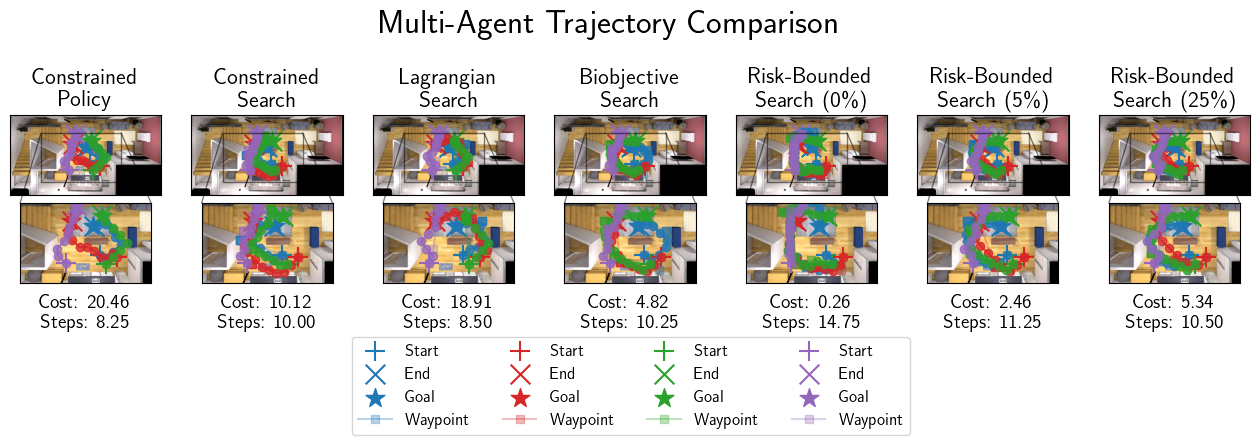

In [32]:
fig, axs = plt.subplots(1, 7, figsize=(16, 3))
height, width = eval_env.get_map_height(), eval_env.get_map_width()

# cost_map = binary_dilation(eval_env.get_map() == 1, structure=np.ones((3,3)), iterations=1)
for ax in axs:
    im = np.asarray(Image.open(illustration_png_file))
    h, w, _ = im.shape
    ax.imshow(im, extent=[0, height+2, 0, width])
    # ax.imshow(im, extent=[0, w, 0, h])
    # ax.imshow(eval_env.get_map()[:, ::-1].T, cmap="binary", interpolation="nearest", alpha=0.5, extent=[0, height, 0, width])
    # cmap = ax.imshow(cost_map[:, ::-1].T, cmap="hot_r", interpolation="nearest", alpha=0.5, extent=[0, height, 0, width])
    ax.set_xticks([])
    ax.set_yticks([])
    
# cbar = plt.colorbar(cmap, ax=axs, orientation="vertical", fraction=0.01, pad=0.04)
# cbar.ax.tick_params(size=0)
# cbar.set_ticks([0, 1, 2])

deltas = [bounds_data["cbs"]["lb"] + RISK_PERCENTAGES[i] * (bounds_data["cbs"]["ub"] - bounds_data["cbs"]["lb"]) for i in range(len(RISK_PERCENTAGES))]
delta_strings = [f"{deltas[i]:.2f}" for i in range(len(deltas))]
delta_percents = [f"{RISK_PERCENTAGES[i] * 100:.0f}\%" for i in range(len(RISK_PERCENTAGES))]  # type: ignore

methods_records_map = {
    "Constrained\nPolicy": (constrained_records, constrained_observations),
    "Constrained\nSearch": (constrained_search_records, constrained_search_observations, constrained_search_waypoints),
    "Lagrangian\nSearch": (lagrangian_search_records, lagrangian_search_observations, lagrangian_search_waypoints),
    "Biobjective\nSearch": (biobjective_search_records, biobjective_search_observations, biobjective_search_waypoints),
    "Risk-Bounded\nSearch 1": (rbu_search_records_0, rbu_search_observations_0, rbu_search_waypoints_0),
    "Risk-Bounded\nSearch 2": (rbu_search_records_1, rbu_search_observations_1, rbu_search_waypoints_1),
    "Risk-Bounded\nSearch 3": (rbu_search_records_2, rbu_search_observations_2, rbu_search_waypoints_2),
}
titles = methods_records_map.keys()

def calculate_costs_and_rewards(records, waypoints=None):
    cc = sum([record["cumulative_costs"] for record in records])
    if waypoints is not None:
        cc = compute_search_cost(waypoints, goal, agent)
    reward = np.mean([record["rewards"] for record in records])
    return cc, reward

for ax, title in zip(axs.flat, list(titles)):
    for agent_id in range(n_agents):
        ax = plot_agent_paths(
            agent_id,
            start[agent_id],
            goal[agent_id],
            methods_records_map[title][1][agent_id],
            title,
            ax,
            wps=methods_records_map[title][2][agent_id] if "Search" in title else None,
        )
    ax_inset = add_inset_axes(
        fig, ax, eval_env,
        start[0], goal[0],
        methods_records_map[title][1][0],
        agent_id=0,
        wps=methods_records_map[title][2][0] if "Search" in title else None,
        xlim=(7, 25), ylim=(3, 14), offsets=(2, -2)
    )
    for agent_id in range(1, n_agents):
        ax_inset = plot_agent_paths(
            agent_id,
            start[agent_id],
            goal[agent_id],
            methods_records_map[title][1][agent_id],
            "",
            ax_inset,
            wps=methods_records_map[title][2][agent_id] if "Search" in title else None,
            use_agent_id=False
        )
    ax.indicate_inset_zoom(ax_inset, edgecolor="black")
    if "Bounded" in title:
        # ax.set_title(title[:-2] + r"$(\Delta=$" + delta_strings.pop(0) + ")", fontsize=16)
        ax.set_title(title[:-2] + " (" + delta_percents.pop(0) + ")", fontsize=16)  # type: ignore
    # cc, reward = calculate_costs_and_rewards(methods_records_map[title][0], 
    #                                          methods_records_map[title][2] if "Search" in title else None)
    cc, reward = calculate_costs_and_rewards(methods_records_map[title][0])
    ax.text(0.5, -1.35, f"Cost: {cc:.2f}", horizontalalignment="center", verticalalignment="center", transform=ax.transAxes, weight='bold', fontsize=14)
    ax.text(0.5, -1.6, f"Steps: {abs(reward):.2f}", horizontalalignment="center", verticalalignment="center", transform=ax.transAxes, weight='bold', fontsize=14)

# cbar.set_label("Cost")
plt.legend(loc="lower center", bbox_to_anchor=(-3.65, -2), ncol=4, fontsize=12)
_ = plt.suptitle("Multi-Agent Trajectory Comparison", fontsize=24)
plt.savefig("pud/plots/figures/paper/safe_multi_agent_habitatenv_comparison.svg", bbox_inches="tight")